Goal: go from the HMF to the UVLF by parameterizing each step in the process \
Following Shen+23

In [14]:
import numpy as np
import zeus21
from classy import Class
import cosmo_calc
import importlib
importlib.reload(cosmo_calc)

<module 'cosmo_calc' from '/Users/eb35267/Desktop/research/escripts/cosmo_calc.py'>

In [15]:
# Parameters that define the cosmology
params = cosmo_calc.get_params()

# HMF

In [16]:
M_vals = np.logspace(7, 14, 100)
_, hmf = cosmo_calc.hmf_zeus(M_vals, params)

# <span style = 'color:red'>The below units are no longer correct because I changed what cosmo_calc.hmf returns<span>

Text(0.5, 1.0, 'HMF from Zeus21')

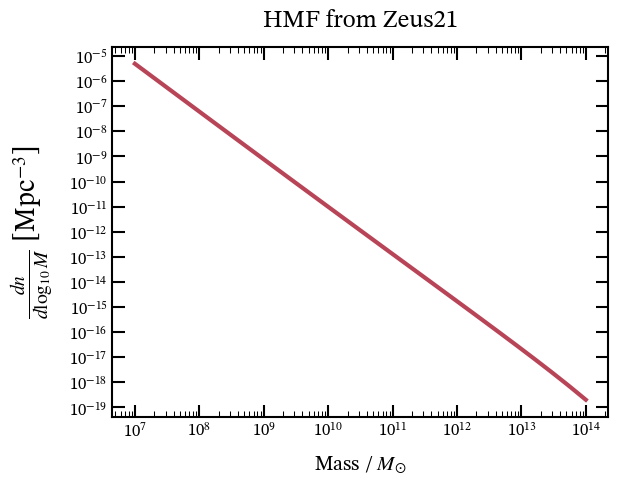

In [17]:
fig, ax = plt.subplots()
ax.loglog(M_vals, hmf)
ax.set_ylabel(r'$\frac{dn}{d\log_{10}M}$ [Mpc$^{-3}$]', fontsize = 20)
ax.set_xlabel(r'Mass / $M_{\odot}$')
ax.set_title('HMF from Zeus21')

# Mass accretion

In [48]:
def m_dot(M_vals, params, z = 0):
    return 25.3*(M_vals/1e12)**(1.1)*(1+(1.65*z))*np.sqrt((params['Omega_m']*(1+z)**3)+params['Omega_L'])

In [49]:
m_dots = m_dot(M_vals, params)

Text(0.5, 1.0, 'Mass accretion rate by halo mass')

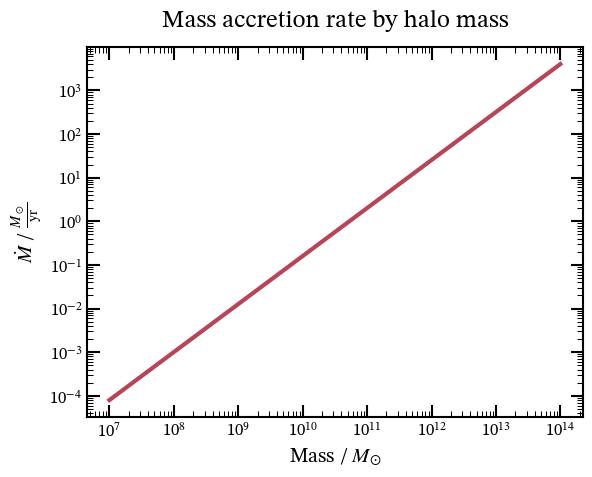

In [60]:
fig, ax = plt.subplots()
ax.loglog(M_vals, m_dots)
ax.set_ylabel(r'$\dot{M}$ / $\frac{M_\odot}{\rm{yr}}$')
ax.set_xlabel(r'Mass / $M_{\odot}$')
ax.set_title('Mass accretion rate by halo mass')